# Laboratorium 3: Klasyfikacja — Indukcja drzew decyzyjnych (CART)


**Zbiory danych:**
- **WINE** — klasyfikacja rodzajów wina (3 klasy, 178 próbek, 13 cech)
- **Polish Companies Bankruptcy (PCB)** — predykcja bankructwa (klasa niezbalansowana)

---

In [66]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Zbiór danych WINE

Zbiór **WINE** zawiera 178 próbek win podzielonych na 3 klasy, opisanych 13 cechami chemicznymi.


In [67]:
from ucimlrepo import fetch_ucirepo

glass = fetch_ucirepo(id=42)
X_glass = glass.data.features
y_glass = glass.data.targets.values.ravel()

feature_names = list(X_glass.columns)
class_names = [str(c) for c in sorted(np.unique(y_glass))]

print(f'Shape: {X_glass.shape}')
print(f'Klasy: {class_names}')
print(f'Rozkład:\n{pd.Series(y_glass).value_counts().sort_index()}')

Shape: (214, 9)
Klasy: ['1', '2', '3', '5', '6', '7']
Rozkład:
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


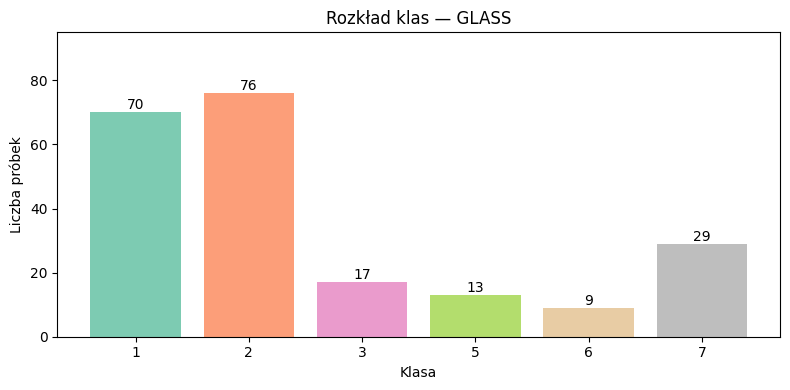

In [68]:
vc = pd.Series(y_glass).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
bars = ax.bar(vc.index.astype(str), vc.values, color=colors, alpha=0.85)
for bar, cnt in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', fontsize=10)
ax.set_title('Rozkład klas — GLASS')
ax.set_ylabel('Liczba próbek')
ax.set_xlabel('Klasa')
ax.set_ylim(0, max(vc.values) * 1.25)
plt.tight_layout()
plt.show()

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_glass.values, y_glass, test_size=0.2, stratify=y_glass
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Rozkład klas train: {np.bincount(y_train)}')
print(f'Rozkład klas test:  {np.bincount(y_test)}')

Train: (171, 9), Test: (43, 9)
Rozkład klas train: [ 0 56 61 14  0 10  7 23]
Rozkład klas test:  [ 0 14 15  3  0  3  2  6]


## 2. Drzewo decyzyjne — domyślne parametry

Trening klasyfikatora bez żadnych ograniczeń. Domyślne drzewo rośnie aż do idealnego dopasowania danych treningowych (accuracy = 100%), co jest klasycznym objawem **przeuczenia (overfitting)**.

In [70]:
from sklearn.metrics import classification_report

def eval_clf(clf, X_train, y_train, X_test, y_test, avg='macro'):
    """Trenuje (jeśli trzeba), wyświetla metryki, zwraca predykcje testowe."""
    if not hasattr(clf, 'classes_'):
        clf.fit(X_train, y_train)
    
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    
    print(f'Głębokość: {clf.get_depth()}, Liście: {clf.get_n_leaves()}')
    print()
    
    metrics = {'Accuracy': accuracy_score, 'Precision': precision_score,
               'Recall': recall_score, 'F1': f1_score}
    
    print(f'{"Metryka":<12} {"Train":>8} {"Test":>8}')
    print('-' * 30)
    for name, fn in metrics.items():
        kw = {} if name == 'Accuracy' else {'average': avg, 'zero_division': 0}
        print(f'{name:<12} {fn(y_train, yp_tr, **kw):>8.4f} {fn(y_test, yp_te, **kw):>8.4f}')
    
    return yp_te

In [71]:
clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)
y_test_pred = eval_clf(clf_default, X_train, y_train, X_test, y_test)

Głębokość: 12, Liście: 41

Metryka         Train     Test
------------------------------
Accuracy       1.0000   0.6512
Precision      1.0000   0.5457
Recall         1.0000   0.5183
F1             1.0000   0.5200


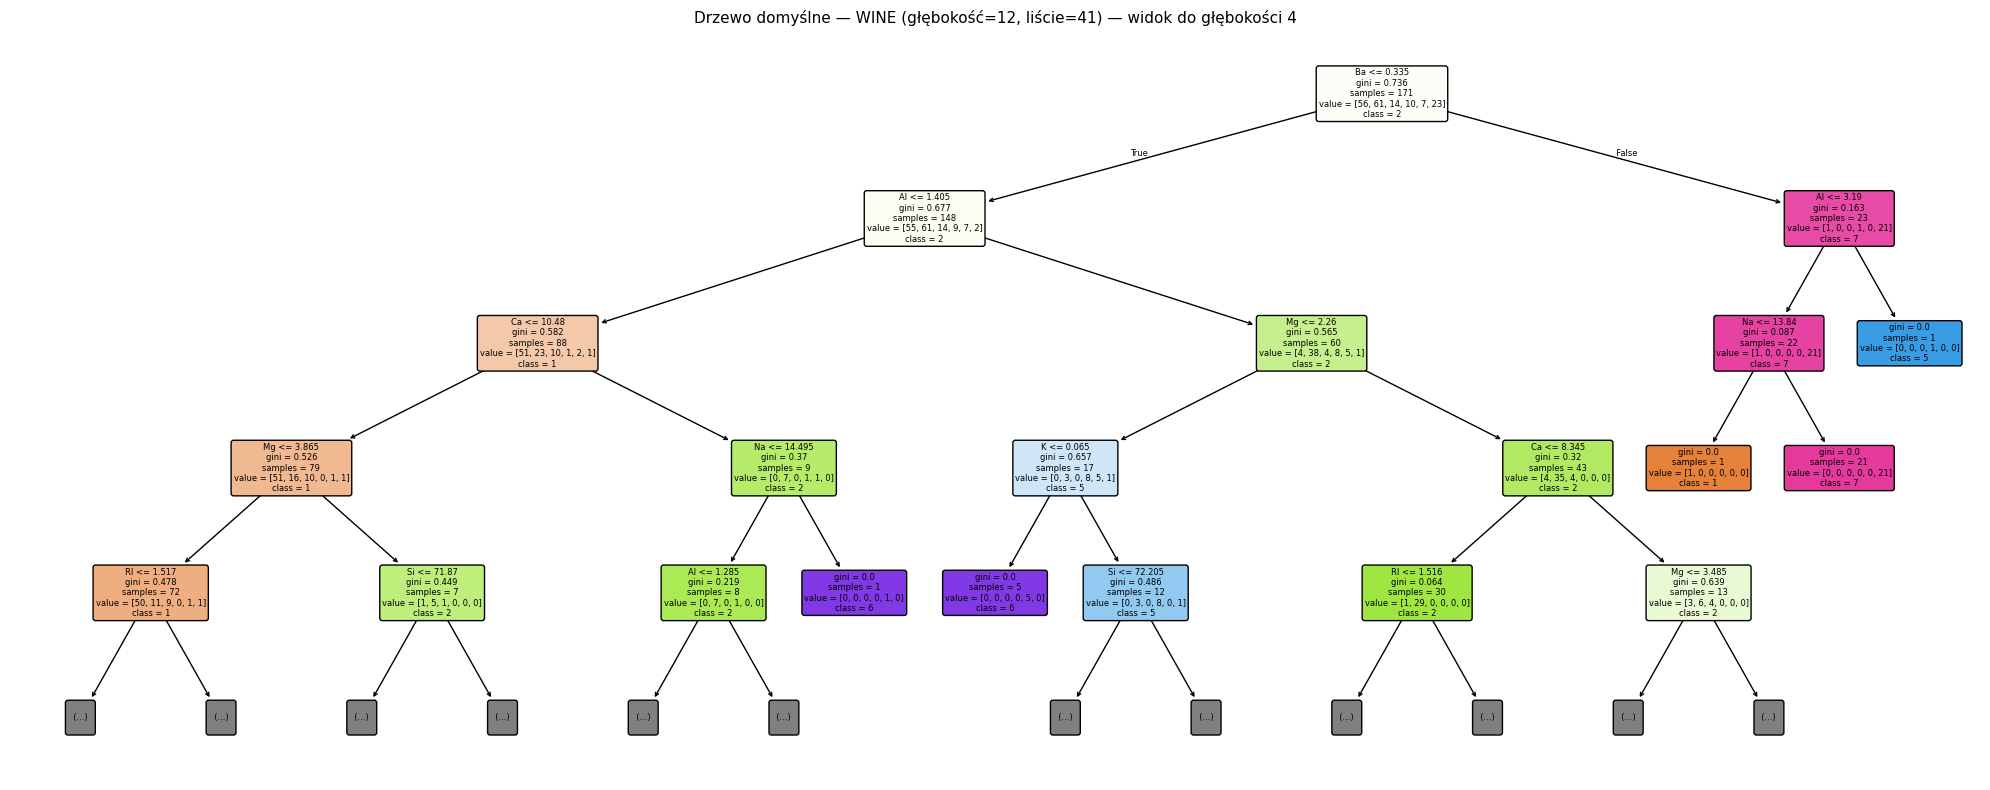

Reprezentacja tekstowa (pierwsze 3 poziomy):
|--- Ba <= 0.34
|   |--- Al <= 1.40
|   |   |--- Ca <= 10.48
|   |   |   |--- Mg <= 3.86
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Mg >  3.86
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Ca >  10.48
|   |   |   |--- Na <= 14.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Na >  14.50
|   |   |   |   |--- class: 6
|   |--- Al >  1.40
|   |   |--- Mg <= 2.26
|   |   |   |--- K <= 0.06
|   |   |   |   |--- class: 6
|   |   |   |--- K >  0.06
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- Mg >  2.26
|   |   |   |--- Ca <= 8.35
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Ca >  8.35
|   |   |   |   |--- truncated branch of depth 4
|--- Ba >  0.34
|   |--- Al <= 3.19
|   |   |--- Na <= 13.84
|   |   |   |--- class: 1
|   |   |--- Na >  13.84
|   |   |   |--- class: 7
|   |--- Al >  3.19
|   |   |--- class: 5



In [72]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(clf_default,
          feature_names=feature_names,
          class_names=class_names,
          filled=True, rounded=True, fontsize=6, max_depth=4, ax=ax)
depth  = clf_default.get_depth()
leaves = clf_default.get_n_leaves()
ax.set_title(
    f'Drzewo domyślne — WINE (głębokość={depth}, liście={leaves}) — widok do głębokości 4',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('Reprezentacja tekstowa (pierwsze 3 poziomy):')
print(export_text(clf_default, feature_names=feature_names, max_depth=3))

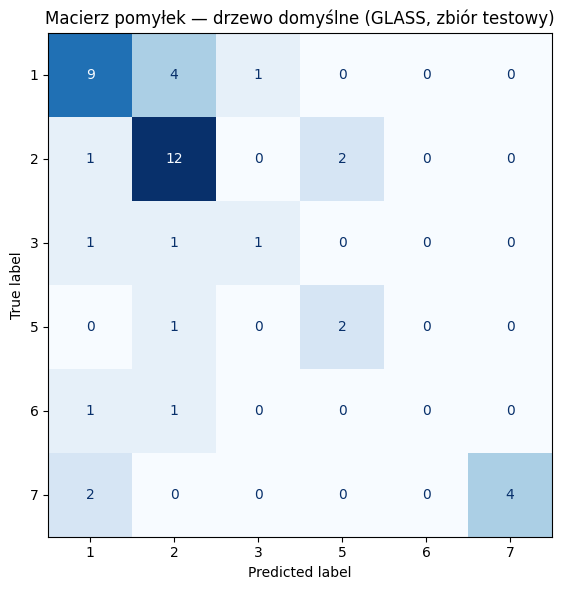

In [73]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — drzewo domyślne (GLASS, zbiór testowy)')
plt.tight_layout()
plt.show()

## 3. Strojenie hiperparametrów

Badamy wpływ trzech kluczowych hiperparametrów na jakość klasyfikacji i rozmiar drzewa.

### 3.1 `max_depth` — ograniczenie głębokości

max_depth sweep:   0%|          | 0/15 [00:00<?, ?it/s]

Najlepsza głębokość (wg CV): max_depth=10, CV acc=0.6814


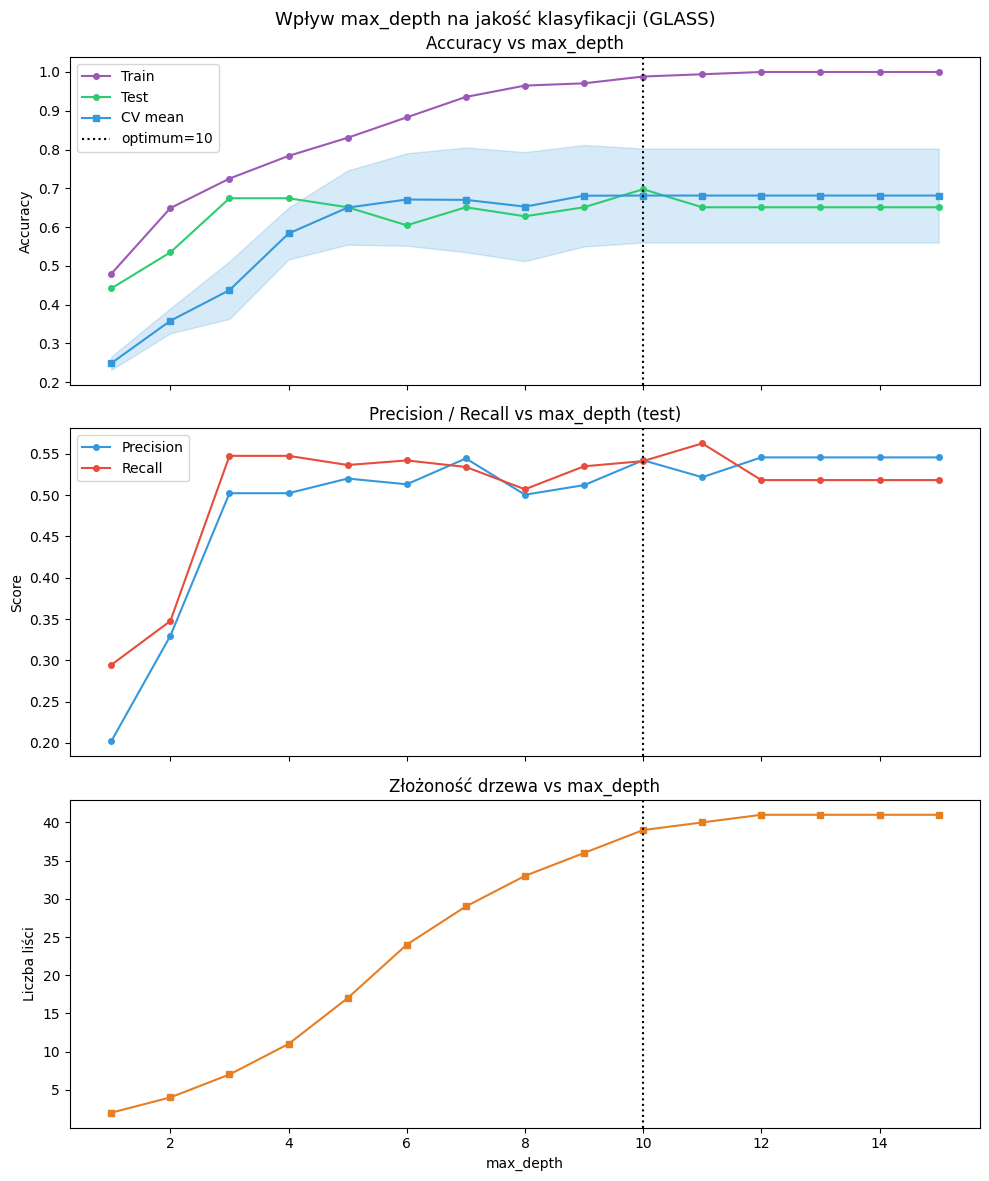

In [74]:
depths = list(range(1, 16))
depth_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for d in tqdm(depths, desc='max_depth sweep'):
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1_macro')
    
    depth_results.append({
        'max_depth': d,
        'train_acc': accuracy_score(y_train, yp_tr),
        'test_acc':  accuracy_score(y_test, yp_te),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'test_prec': precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':  recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':  clf.get_n_leaves(),
    })

df_depth = pd.DataFrame(depth_results).set_index('max_depth')
best_depth = int(df_depth['cv_mean'].idxmax())
print(f'Najlepsza głębokość (wg CV): max_depth={best_depth}, CV acc={df_depth.loc[best_depth, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Accuracy: train / test / CV
axes[0].plot(df_depth.index, df_depth['train_acc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_depth.index, df_depth['test_acc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_depth.index, df_depth['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean')
axes[0].fill_between(df_depth.index,
                     df_depth['cv_mean'] - df_depth['cv_std'],
                     df_depth['cv_mean'] + df_depth['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_depth, color='black', linestyle=':', label=f'optimum={best_depth}')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs max_depth')
axes[0].legend()

# 2) Precision / Recall
axes[1].plot(df_depth.index, df_depth['test_prec'], color='#3498db', marker='o', markersize=4, label='Precision')
axes[1].plot(df_depth.index, df_depth['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall')
axes[1].axvline(best_depth, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs max_depth (test)')
axes[1].legend()

# 3) Złożoność
axes[2].plot(df_depth.index, df_depth['n_leaves'], color='#e67e22', marker='s', markersize=4)
axes[2].axvline(best_depth, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści')
axes[2].set_xlabel('max_depth')
axes[2].set_title('Złożoność drzewa vs max_depth')

plt.suptitle('Wpływ max_depth na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 `min_samples_leaf` — minimalna liczba próbek w liściu



min_samples_leaf sweep:   0%|          | 0/30 [00:00<?, ?it/s]

Najlepsze min_samples_leaf (wg CV): 3, CV acc=0.6908


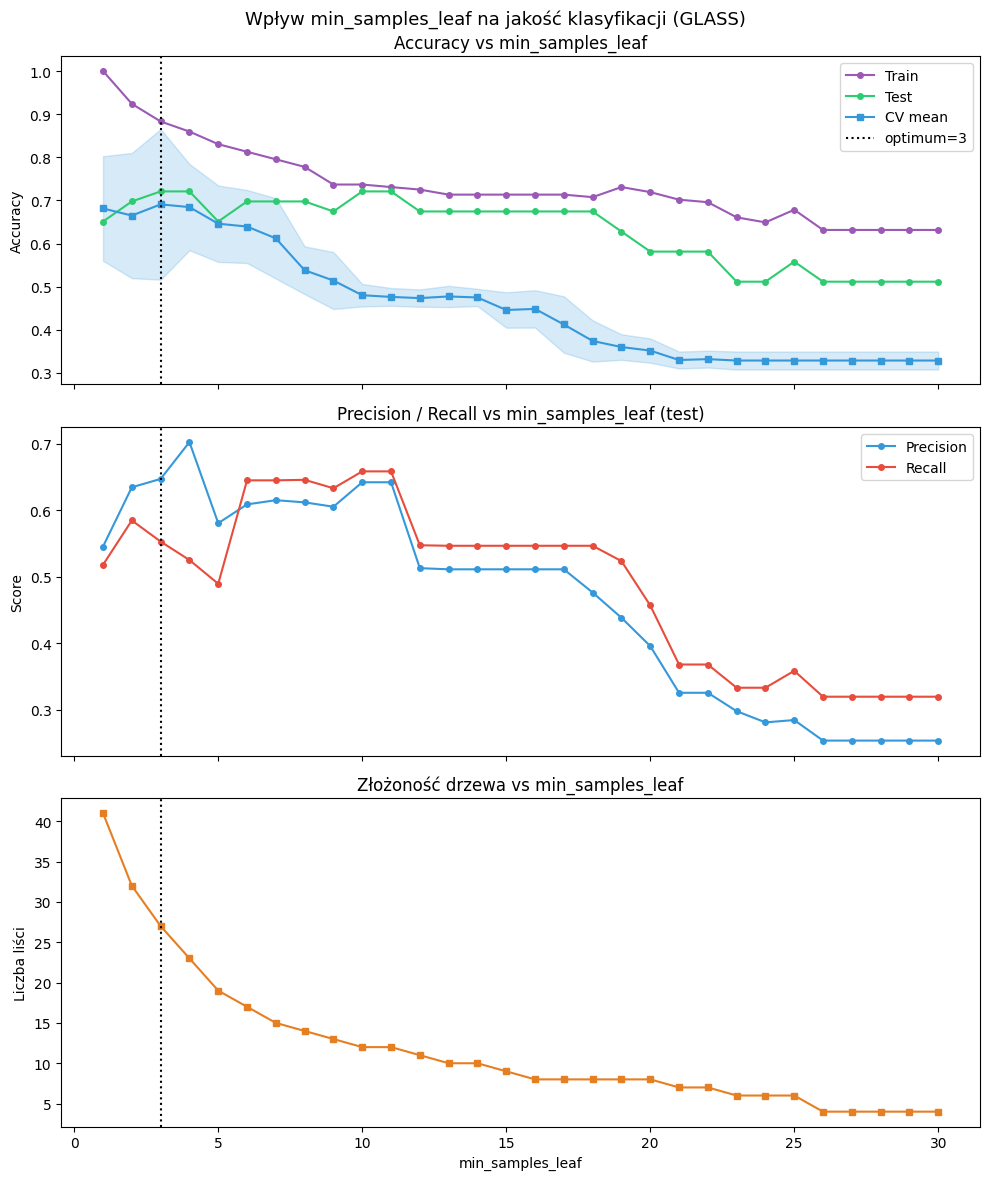

In [75]:
min_samples_values = list(range(1, 31))
leaf_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ms in tqdm(min_samples_values, desc='min_samples_leaf sweep'):
    clf = DecisionTreeClassifier(min_samples_leaf=ms, random_state=42)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1_macro')
    
    leaf_results.append({
        'min_samples_leaf': ms,
        'train_acc': accuracy_score(y_train, yp_tr),
        'test_acc':  accuracy_score(y_test, yp_te),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'test_prec': precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':  recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':  clf.get_n_leaves(),
    })

df_leaf = pd.DataFrame(leaf_results).set_index('min_samples_leaf')
best_ms = int(df_leaf['cv_mean'].idxmax())
print(f'Najlepsze min_samples_leaf (wg CV): {best_ms}, CV acc={df_leaf.loc[best_ms, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(df_leaf.index, df_leaf['train_acc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_leaf.index, df_leaf['test_acc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_leaf.index, df_leaf['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean')
axes[0].fill_between(df_leaf.index,
                     df_leaf['cv_mean'] - df_leaf['cv_std'],
                     df_leaf['cv_mean'] + df_leaf['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_ms, color='black', linestyle=':', label=f'optimum={best_ms}')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs min_samples_leaf')
axes[0].legend()

axes[1].plot(df_leaf.index, df_leaf['test_prec'], color='#3498db', marker='o', markersize=4, label='Precision')
axes[1].plot(df_leaf.index, df_leaf['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall')
axes[1].axvline(best_ms, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs min_samples_leaf (test)')
axes[1].legend()

axes[2].plot(df_leaf.index, df_leaf['n_leaves'], color='#e67e22', marker='s', markersize=4)
axes[2].axvline(best_ms, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_title('Złożoność drzewa vs min_samples_leaf')

plt.suptitle('Wpływ min_samples_leaf na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Przycinanie drzewa — `ccp_alpha` (Cost-Complexity Pruning)

**Pruning post-hoc:** sklearn oblicza ścieżkę regularyzacji — kolejne wartości `ccp_alpha` odpowiadają etapom upraszczania drzewa. Większe `alpha` → prostsze drzewo. Parametr ten jest jedną z najbardziej skutecznych metod regularyzacji drzew decyzyjnych.

Liczba kroków pruning path: 29
Zakres ccp_alpha: [0.000000, 0.088081]


ccp_alpha sweep:   0%|          | 0/29 [00:00<?, ?it/s]

Najlepsza ccp_alpha (wg CV): 0.013367, CV acc=0.7032
Wynikowe drzewo: głębokość=8, liście=16


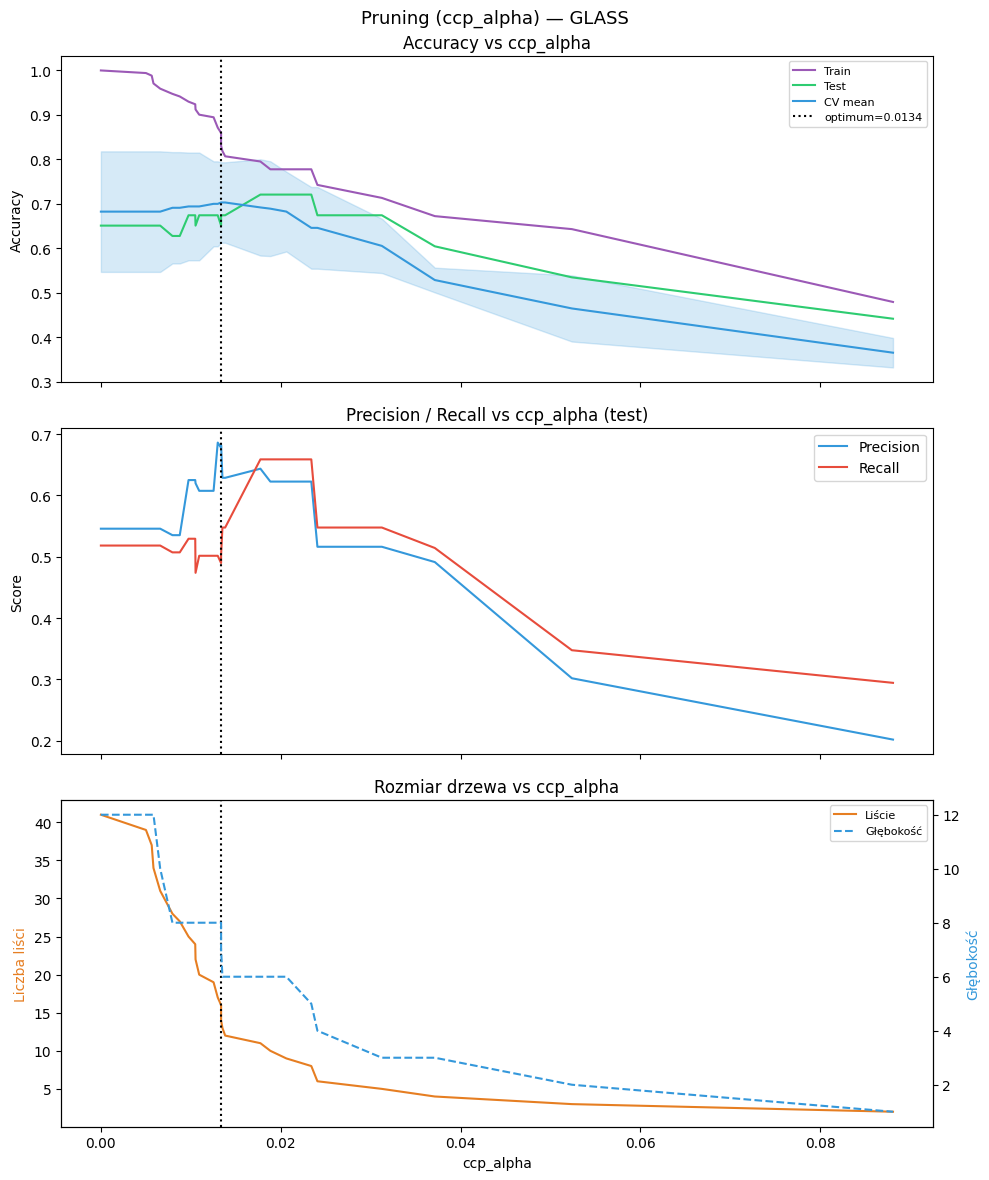

In [76]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Liczba kroków pruning path: {len(ccp_alphas)}')
print(f'Zakres ccp_alpha: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]')

alpha_results = []
for alpha in tqdm(ccp_alphas, desc='ccp_alpha sweep'):
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')
    
    alpha_results.append({
        'ccp_alpha': alpha,
        'train_acc': accuracy_score(y_train, yp_tr),
        'test_acc':  accuracy_score(y_test, yp_te),
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'test_prec': precision_score(y_test, yp_te, average='macro', zero_division=0),
        'test_rec':  recall_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':  clf.get_n_leaves(),
        'depth':     clf.get_depth(),
    })

df_alpha = pd.DataFrame(alpha_results)
best_alpha_idx = df_alpha['cv_mean'].idxmax()
best_row       = df_alpha.loc[best_alpha_idx]
best_alpha     = float(best_row['ccp_alpha'])

print(f'Najlepsza ccp_alpha (wg CV): {best_alpha:.6f}, CV acc={best_row["cv_mean"]:.4f}')
print(f'Wynikowe drzewo: głębokość={int(best_row["depth"])}, liście={int(best_row["n_leaves"])}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Accuracy
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['train_acc'], color='#9b59b6', linewidth=1.5, label='Train')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['test_acc'],  color='#2ecc71', linewidth=1.5, label='Test')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['cv_mean'],   color='#3498db', linewidth=1.5, label='CV mean')
axes[0].fill_between(df_alpha['ccp_alpha'],
                     df_alpha['cv_mean'] - df_alpha['cv_std'],
                     df_alpha['cv_mean'] + df_alpha['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_alpha, color='black', linestyle=':', label=f'optimum={best_alpha:.4f}')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs ccp_alpha')
axes[0].legend(fontsize=8)

# 2) Precision / Recall
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['test_prec'], color='#3498db', linewidth=1.5, label='Precision')
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['test_rec'],  color='#e74c3c', linewidth=1.5, label='Recall')
axes[1].axvline(best_alpha, color='black', linestyle=':')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall vs ccp_alpha (test)')
axes[1].legend()

# 3) Rozmiar drzewa — liście + głębokość na dwóch osiach
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_alpha['ccp_alpha'], df_alpha['n_leaves'], color='#e67e22', linewidth=1.5, label='Liście')
ax_depth.plot(df_alpha['ccp_alpha'], df_alpha['depth'],     color='#3498db', linewidth=1.5, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_alpha, color='black', linestyle=':')
ax_leaves.set_xlabel('ccp_alpha')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Głębokość', color='#3498db')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax_leaves.set_title('Rozmiar drzewa vs ccp_alpha')

plt.suptitle('Pruning (ccp_alpha) — GLASS', fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 GridSearchCV — automatyczne strojenie

GridSearchCV z `StratifiedKFold(n_splits=5)` przeszukuje przestrzeń hiperparametrów i wybiera najlepszy zestaw według `f1_macro`.

In [77]:
param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 3, 5, 10],
    'ccp_alpha':        [0.0, 0.001, 0.005, 0.01],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f'Najlepsze parametry: {grid_search.best_params_}')
print(f'Najlepsza F1 (CV):   {grid_search.best_score_:.4f}')

clf_best = grid_search.best_estimator_
y_best_pred = clf_best.predict(X_test)

print()
print('{:<15} {:>8}'.format('Metryka', 'Test'))
print('-' * 25)
for name, val in [
    ('Accuracy',   accuracy_score(y_test,  y_best_pred)),
    ('Precision',  precision_score(y_test, y_best_pred, average='macro', zero_division=0)),
    ('Recall',     recall_score(y_test,    y_best_pred, average='macro', zero_division=0)),
    ('F1 (macro)', f1_score(y_test,        y_best_pred, average='macro', zero_division=0)),
]:
    print('{:<15} {:>8.4f}'.format(name, val))
print(f'Głębokość: {clf_best.get_depth()}, Liście: {clf_best.get_n_leaves()}')

Najlepsze parametry: {'ccp_alpha': 0.01, 'max_depth': None, 'min_samples_leaf': 2}
Najlepsza F1 (CV):   0.6944

Metryka             Test
-------------------------
Accuracy          0.6744
Precision         0.5988
Recall            0.5294
F1 (macro)        0.5522
Głębokość: 8, Liście: 23


### 3.5 Wizualizacja wybranych drzew

Porównanie czterech reprezentatywnych wariantów: za małe, za duże (domyślne), po pruningu i optymalne (GridSearchCV).

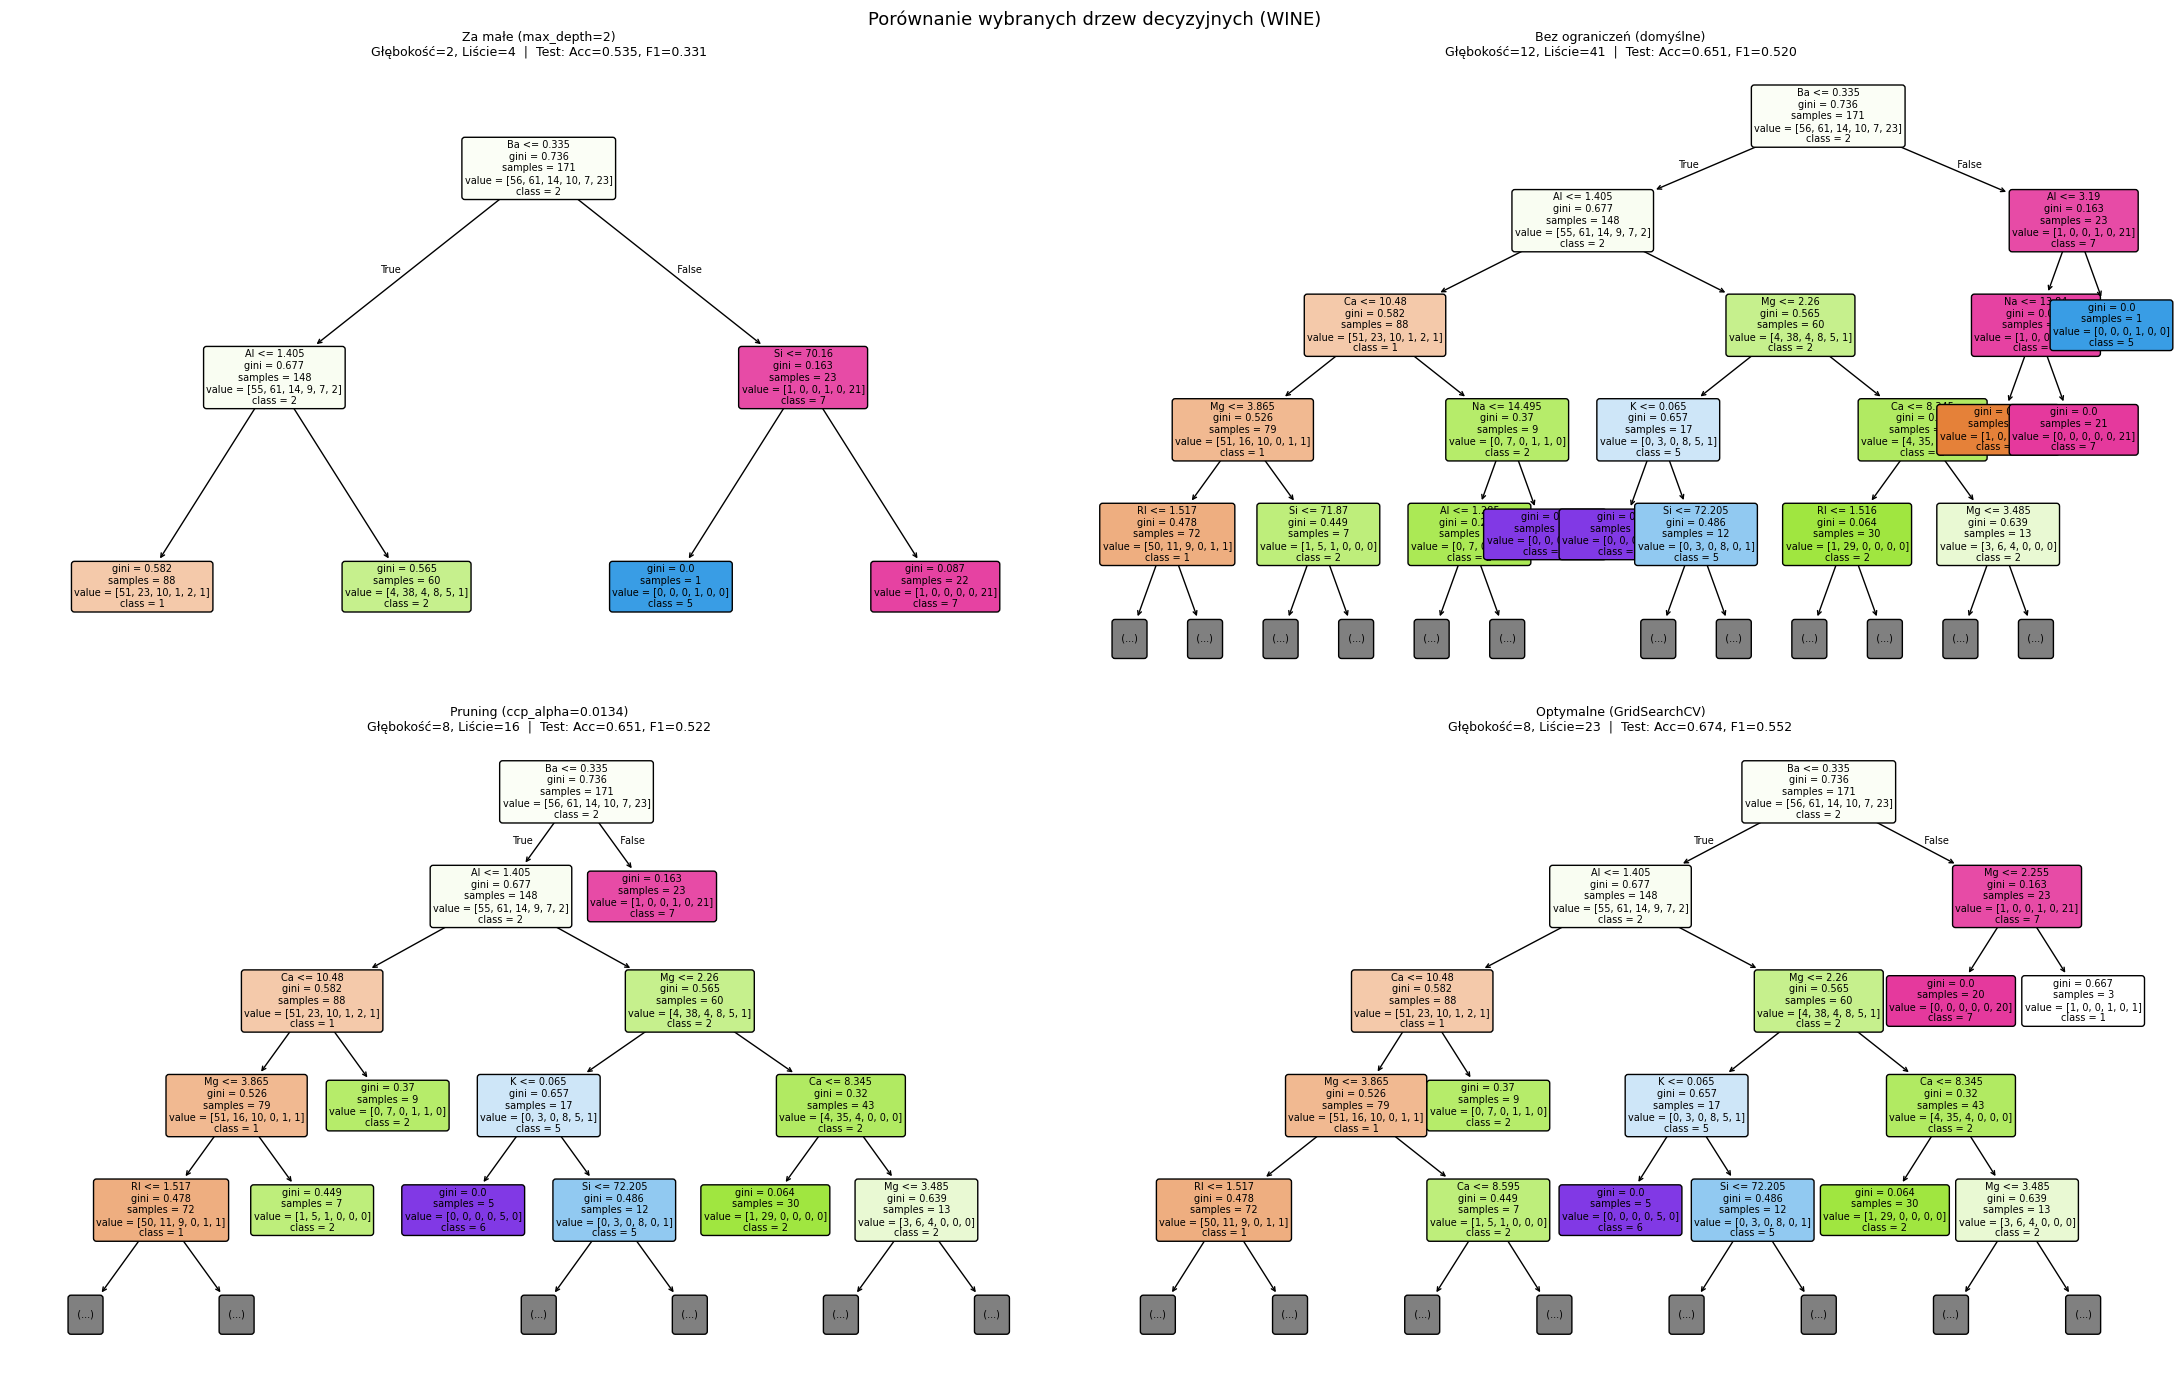

In [78]:
clf_small  = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
clf_full   = DecisionTreeClassifier(random_state=42)

clf_small.fit(X_train, y_train)
clf_pruned.fit(X_train, y_train)
clf_full.fit(X_train, y_train)

tree_variants = [
    ('Za małe (max_depth=2)',                   clf_small),
    ('Bez ograniczeń (domyślne)',               clf_full),
    (f'Pruning (ccp_alpha={best_alpha:.4f})',   clf_pruned),
    ('Optymalne (GridSearchCV)',                clf_best),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

for ax, (title, clf) in zip(axes.flatten(), tree_variants):
    yp  = clf.predict(X_test)
    f1  = f1_score(y_test, yp, average='macro', zero_division=0)
    acc = accuracy_score(y_test, yp)
    d   = clf.get_depth()
    nl  = clf.get_n_leaves()
    plot_tree(clf, feature_names=feature_names, class_names=class_names,
              filled=True, rounded=True, fontsize=7, max_depth=4, ax=ax)
    ax.set_title(
        f'{title}\nGłębokość={d}, Liście={nl}  |  Test: Acc={acc:.3f}, F1={f1:.3f}',
        fontsize=9
    )

plt.suptitle('Porównanie wybranych drzew decyzyjnych (WINE)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 Ważność cech (Feature Importance)

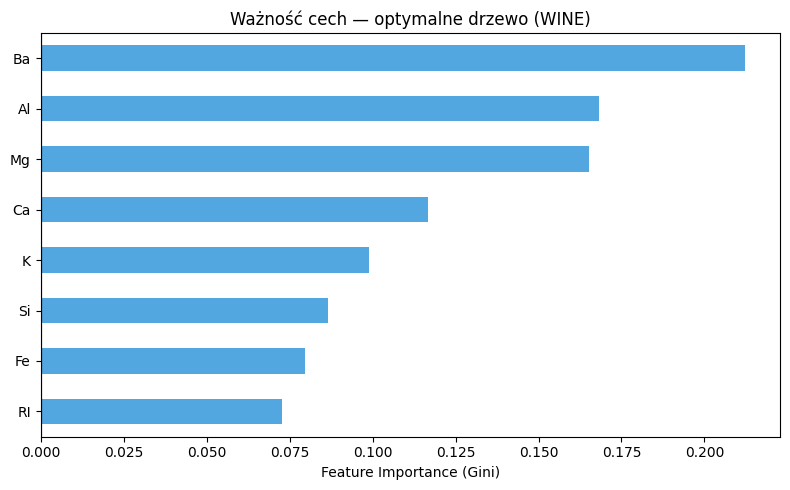

Top cechy (malejąco):
  Ba                             0.2121
  Al                             0.1683
  Mg                             0.1651
  Ca                             0.1166
  K                              0.0988
  Si                             0.0866
  Fe                             0.0796
  RI                             0.0728


In [79]:
imp_df = pd.Series(clf_best.feature_importances_, index=feature_names).sort_values()
imp_df = imp_df[imp_df > 0]

fig, ax = plt.subplots(figsize=(8, 5))
imp_df.plot.barh(ax=ax, color='#3498db', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ważność cech — optymalne drzewo (WINE)')
ax.set_xlabel('Feature Importance (Gini)')
plt.tight_layout()
plt.show()

print('Top cechy (malejąco):')
for feat, val in imp_df.sort_values(ascending=False).items():
    print(f'  {feat:<30} {val:.4f}')

## 4. Walidacja krzyżowa: zwykła vs stratyfikowana

**KFold** losowo dzieli dane na foldy bez zachowania proporcji klas.  
**StratifiedKFold** gwarantuje, że każdy fold ma podobną proporcję klas jak cały zbiór — szczególnie ważne przy niezbalansowanych zbiorach.

Metoda                     Mean      Std  Wyniki foldów
------------------------------------------------------------------------
KFold                    0.9000   0.0292  [0.9432 0.9195 0.8932 0.8866 0.8576]
StratifiedKFold          0.8748   0.0414  [0.8928 0.8642 0.8355 0.8357 0.9458]


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_76789/805683815.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([scores_kf, scores_skf],


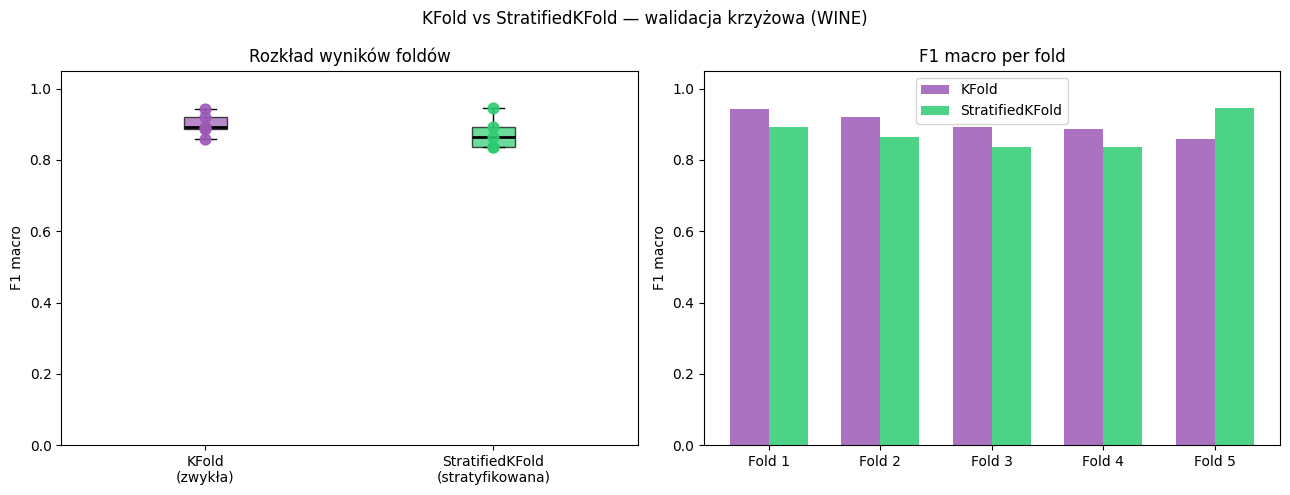

In [80]:
best_params = grid_search.best_params_
clf_cv = DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    ccp_alpha=best_params['ccp_alpha'],
    random_state=42,
)

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_kf  = cross_val_score(clf_cv, X_wine, y_wine, cv=kf,  scoring='f1_macro')
scores_skf = cross_val_score(clf_cv, X_wine, y_wine, cv=skf, scoring='f1_macro')

print('{:<22} {:>8} {:>8}  {}'.format('Metoda', 'Mean', 'Std', 'Wyniki foldów'))
print('-' * 72)
print('{:<22} {:>8.4f} {:>8.4f}  {}'.format('KFold', scores_kf.mean(), scores_kf.std(), np.round(scores_kf, 4)))
print('{:<22} {:>8.4f} {:>8.4f}  {}'.format('StratifiedKFold', scores_skf.mean(), scores_skf.std(), np.round(scores_skf, 4)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bp = axes[0].boxplot([scores_kf, scores_skf],
                     labels=['KFold\n(zwykła)', 'StratifiedKFold\n(stratyfikowana)'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9b59b6', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(2)
axes[0].scatter([1]*len(scores_kf),  scores_kf,  color='#9b59b6', zorder=5, s=60, alpha=0.9)
axes[0].scatter([2]*len(scores_skf), scores_skf, color='#2ecc71', zorder=5, s=60, alpha=0.9)
axes[0].set_title('Rozkład wyników foldów')
axes[0].set_ylabel('F1 macro')
axes[0].set_ylim(0, 1.05)

x = np.arange(5)
width = 0.35
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
axes[1].bar(x - width/2, scores_kf,  width, color='#9b59b6', alpha=0.85, label='KFold')
axes[1].bar(x + width/2, scores_skf, width, color='#2ecc71', alpha=0.85, label='StratifiedKFold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_title('F1 macro per fold')
axes[1].set_ylabel('F1 macro')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('KFold vs StratifiedKFold — walidacja krzyżowa (WINE)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Zbiór Polish Companies Bankruptcy (PCB)


### 5.1 Wczytanie i preprocessing

In [81]:
print('Wczytywanie Polish Companies Bankruptcy (UCI id=365)...')
dataset = fetch_ucirepo(id=365)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df_pcb = X_raw.copy()
df_pcb['class'] = y_raw['class'].values

print(f'Pełny zbiór: {df_pcb.shape}')
years = sorted(df_pcb['year'].unique())
print(f'Lata: {years}')

df4 = df_pcb[df_pcb['year'] == 4].drop(columns=['year', 'A37'])
feat_cols_pcb = [c for c in df4.columns if c != 'class']
df4 = df4[df4[feat_cols_pcb].isnull().sum(axis=1) <= 7].reset_index(drop=True)

X_pcb = df4[feat_cols_pcb]
y_pcb = df4['class'].astype(int)

print(f'Po filtracji (rok 4, maks. 7 braków): {df4.shape}')
print(f'Bankruci:  {y_pcb.sum()} ({100*y_pcb.mean():.1f}%)')
print(f'Solwentni: {(y_pcb == 0).sum()} ({100*(1-y_pcb.mean()):.1f}%)')

X_pcb_train_raw, X_pcb_test_raw, y_pcb_train, y_pcb_test = train_test_split(
    X_pcb, y_pcb, test_size=0.2, stratify=y_pcb, random_state=42
)

# DT nie wymaga skalowania — tylko imputacja brakujących wartości
imputer = SimpleImputer(strategy='median')
X_pcb_train = imputer.fit_transform(X_pcb_train_raw)
X_pcb_test  = imputer.transform(X_pcb_test_raw)

print(f'Train: {X_pcb_train.shape}  |  Test: {X_pcb_test.shape}')
print(f'Bankruci train: {y_pcb_train.sum()} ({100*y_pcb_train.mean():.1f}%)')

Wczytywanie Polish Companies Bankruptcy (UCI id=365)...
Pełny zbiór: (43405, 66)
Lata: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Po filtracji (rok 4, maks. 7 braków): (9719, 64)
Bankruci:  508 (5.2%)
Solwentni: 9211 (94.8%)
Train: (7775, 63)  |  Test: (1944, 63)
Bankruci train: 406 (5.2%)


### 5.2 Drzewo decyzyjne — domyślne parametry (PCB)

Głębokość: 31, Liście: 322

Metryka            Train     Test
-----------------------------------
Accuracy          1.0000   0.9275
Precision         1.0000   0.3415
Recall            1.0000   0.4118
F1                1.0000   0.3733


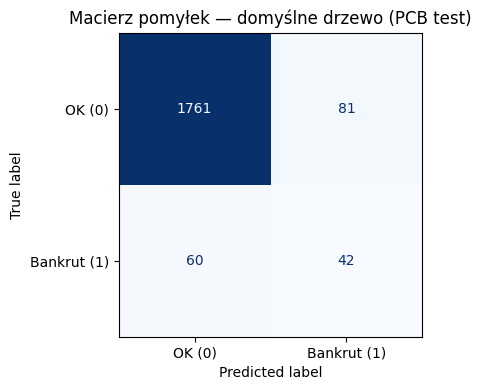

In [82]:
clf_pcb_default = DecisionTreeClassifier(random_state=42)
clf_pcb_default.fit(X_pcb_train, y_pcb_train)

y_pcb_train_pred = clf_pcb_default.predict(X_pcb_train)
y_pcb_test_pred  = clf_pcb_default.predict(X_pcb_test)

print(f'Głębokość: {clf_pcb_default.get_depth()}, Liście: {clf_pcb_default.get_n_leaves()}')
print()
print('{:<15} {:>8} {:>8}'.format('Metryka', 'Train', 'Test'))
print('-' * 35)
for name, tr, te in [
    ('Accuracy',  accuracy_score(y_pcb_train, y_pcb_train_pred),
                  accuracy_score(y_pcb_test,  y_pcb_test_pred)),
    ('Precision', precision_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  precision_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('Recall',    recall_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  recall_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('F1',        f1_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  f1_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
]:
    print('{:<15} {:>8.4f} {:>8.4f}'.format(name, tr, te))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_pcb_test, y_pcb_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — domyślne drzewo (PCB test)')
plt.tight_layout()
plt.show()

### 5.3 Wpływ parametru `class_weight`

class_weight:   0%|          | 0/5 [00:00<?, ?it/s]

,Accuracy,Precision,Recall,F1,Głębokość,Liście
class_weight,,,,,,
None,0.9275,0.3415,0.4118,0.3733,31,322
balanced,0.9198,0.2672,0.3039,0.2844,40,398
"{0:1, 1:5}",0.9270,0.3148,0.3333,0.3238,27,298
"{0:1, 1:10}",0.9378,0.4000,0.3725,0.3858,29,315
"{0:1, 1:20}",0.9295,0.3118,0.2843,0.2974,44,354


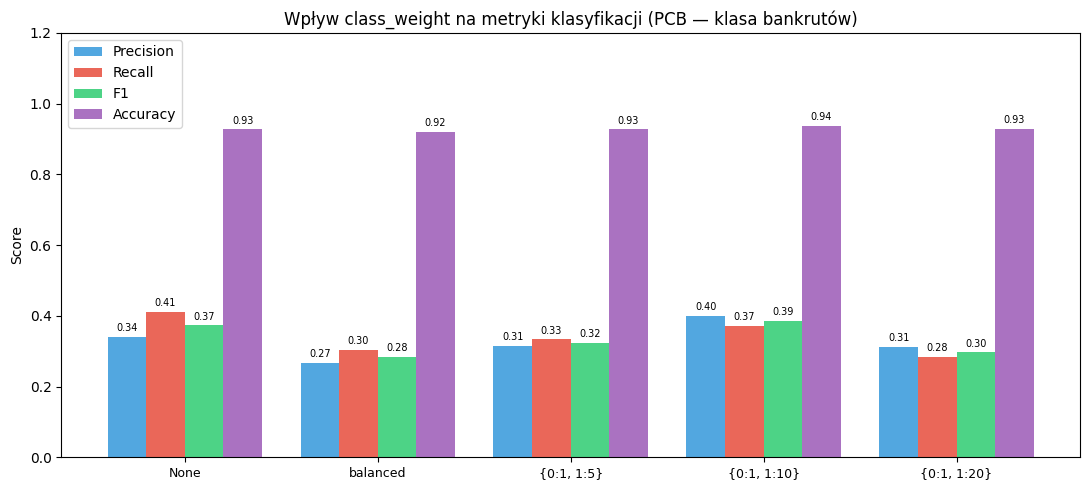

In [83]:
class_weight_variants = [
    ('None',        None),
    ('balanced',    'balanced'),
    ('{0:1, 1:5}',  {0: 1, 1: 5}),
    ('{0:1, 1:10}', {0: 1, 1: 10}),
    ('{0:1, 1:20}', {0: 1, 1: 20}),
]

cw_results = []
for name, cw in tqdm(class_weight_variants, desc='class_weight'):
    clf = DecisionTreeClassifier(class_weight=cw, random_state=42)
    clf.fit(X_pcb_train, y_pcb_train)
    yp = clf.predict(X_pcb_test)
    cw_results.append({
        'class_weight': name,
        'Accuracy':  accuracy_score(y_pcb_test, yp),
        'Precision': precision_score(y_pcb_test, yp, zero_division=0),
        'Recall':    recall_score(y_pcb_test,    yp, zero_division=0),
        'F1':        f1_score(y_pcb_test,        yp, zero_division=0),
        'Głębokość': clf.get_depth(),
        'Liście':    clf.get_n_leaves(),
    })

df_cw = pd.DataFrame(cw_results).set_index('class_weight')
display(df_cw.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_cw))
width = 0.2
metrics_colors = [('Precision', '#3498db'), ('Recall', '#e74c3c'), ('F1', '#2ecc71'), ('Accuracy', '#9b59b6')]
offsets = [-1.5, -0.5, 0.5, 1.5]

for (metric, color), offset in zip(metrics_colors, offsets):
    bars = ax.bar(x + offset * width, df_cw[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_cw.index, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title('Wpływ class_weight na metryki klasyfikacji (PCB — klasa bankrutów)')
ax.legend()
plt.tight_layout()
plt.show()

> **Obserwacja:** Wzrost wagi klasy bankrutów (`1`) wyraźnie zwiększa **Recall** (wykrywalność bankructw) kosztem **Precision** (więcej fałszywych alarmów) i **Accuracy** (ogólna dokładność spada, bo model błędnie klasyfikuje więcej solwentnych firm). Dobór `class_weight` to biznesowy kompromis: w finansach minimalizacja przeoczonych bankructw (False Negatives) jest zazwyczaj ważniejsza niż fałszywe alarmy.

### 5.4 Strojenie hiperparametrów + class_weight (GridSearchCV — PCB)

Optymalizujemy pod kątem **Recall** klasy bankrutów — w zastosowaniach finansowych przeoczenie bankructwa (FN) jest droższe niż fałszywy alarm (FP).

Najlepsze parametry: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1}
Najlepsza Recall (CV): 0.6871

Metryka             Test
-------------------------
Accuracy          0.7263
Precision         0.1033
Recall            0.5490
F1                0.1739


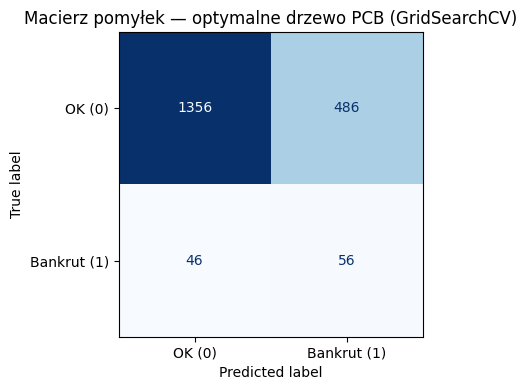

In [84]:
param_grid_pcb = {
    'max_depth':        [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight':     [None, 'balanced', {0: 1, 1: 10}],
}

grid_pcb = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_pcb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1,
)
grid_pcb.fit(X_pcb_train, y_pcb_train)

print(f'Najlepsze parametry: {grid_pcb.best_params_}')
print(f'Najlepsza Recall (CV): {grid_pcb.best_score_:.4f}')

clf_pcb_best = grid_pcb.best_estimator_
yp_best_pcb  = clf_pcb_best.predict(X_pcb_test)

print()
print('{:<15} {:>8}'.format('Metryka', 'Test'))
print('-' * 25)
for name, val in [
    ('Accuracy',  accuracy_score(y_pcb_test,  yp_best_pcb)),
    ('Precision', precision_score(y_pcb_test, yp_best_pcb, zero_division=0)),
    ('Recall',    recall_score(y_pcb_test,    yp_best_pcb, zero_division=0)),
    ('F1',        f1_score(y_pcb_test,        yp_best_pcb, zero_division=0)),
]:
    print('{:<15} {:>8.4f}'.format(name, val))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_pcb_test, yp_best_pcb)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — optymalne drzewo PCB (GridSearchCV)')
plt.tight_layout()
plt.show()

## 6. Podsumowanie wyników

### 6.1 WINE — porównanie modeli

=== WINE — metryki testowe ===


,Acc,Prec,Rec,F1,Głęb.,Liście
Model,,,,,,
Domyślne,0.6512,0.5457,0.5183,0.5200,12,41
max_depth=2,0.5349,0.3297,0.3476,0.3311,2,4
max_depth=10,0.6977,0.5422,0.5413,0.5340,10,39
min_samples_leaf=3,0.7209,0.6474,0.5532,0.5695,9,27
ccp_alpha=0.0134,0.6512,0.6775,0.4897,0.5222,8,16
GridSearchCV (opt.),0.6744,0.5988,0.5294,0.5522,8,23


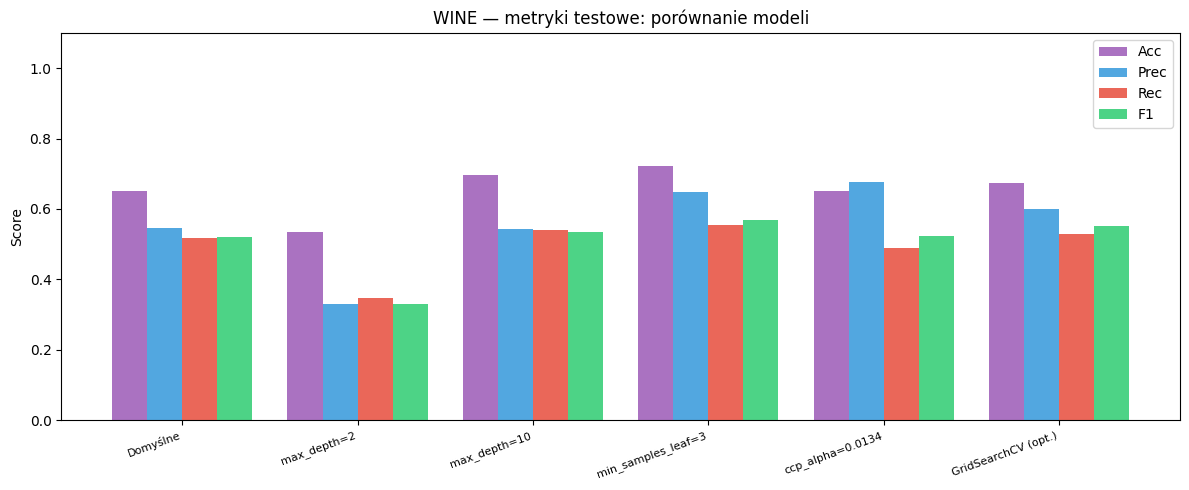

In [85]:
wine_summary_models = [
    ('Domyślne',                    DecisionTreeClassifier(random_state=42)),
    ('max_depth=2',                 DecisionTreeClassifier(max_depth=2, random_state=42)),
    (f'max_depth={best_depth}',     DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
    (f'min_samples_leaf={best_ms}', DecisionTreeClassifier(min_samples_leaf=best_ms, random_state=42)),
    (f'ccp_alpha={best_alpha:.4f}', DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)),
    ('GridSearchCV (opt.)',          clf_best),
]

wine_rows = []
for name, clf in wine_summary_models:
    if not hasattr(clf, 'tree_'):
        clf.fit(X_train, y_train)
    yp = clf.predict(X_test)
    wine_rows.append({
        'Model':   name,
        'Acc':     accuracy_score(y_test,  yp),
        'Prec':    precision_score(y_test, yp, average='macro', zero_division=0),
        'Rec':     recall_score(y_test,    yp, average='macro', zero_division=0),
        'F1':      f1_score(y_test,        yp, average='macro', zero_division=0),
        'Głęb.':  clf.get_depth(),
        'Liście': clf.get_n_leaves(),
    })

df_wine_summary = pd.DataFrame(wine_rows).set_index('Model')
print('=== WINE — metryki testowe ===')
display(df_wine_summary.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_wine_summary))
width = 0.2
for i, (metric, color) in enumerate([
    ('Acc',  '#9b59b6'),
    ('Prec', '#3498db'),
    ('Rec',  '#e74c3c'),
    ('F1',   '#2ecc71'),
]):
    ax.bar(x + (i - 1.5) * width, df_wine_summary[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_wine_summary.index, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('WINE — metryki testowe: porównanie modeli')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 PCB — wpływ class_weight

=== PCB — wpływ class_weight (zbiór testowy) ===


,Accuracy,Precision,Recall,F1,Głębokość,Liście
class_weight,,,,,,
None,0.9275,0.3415,0.4118,0.3733,31,322
balanced,0.9198,0.2672,0.3039,0.2844,40,398
"{0:1, 1:5}",0.9270,0.3148,0.3333,0.3238,27,298
"{0:1, 1:10}",0.9378,0.4000,0.3725,0.3858,29,315
"{0:1, 1:20}",0.9295,0.3118,0.2843,0.2974,44,354


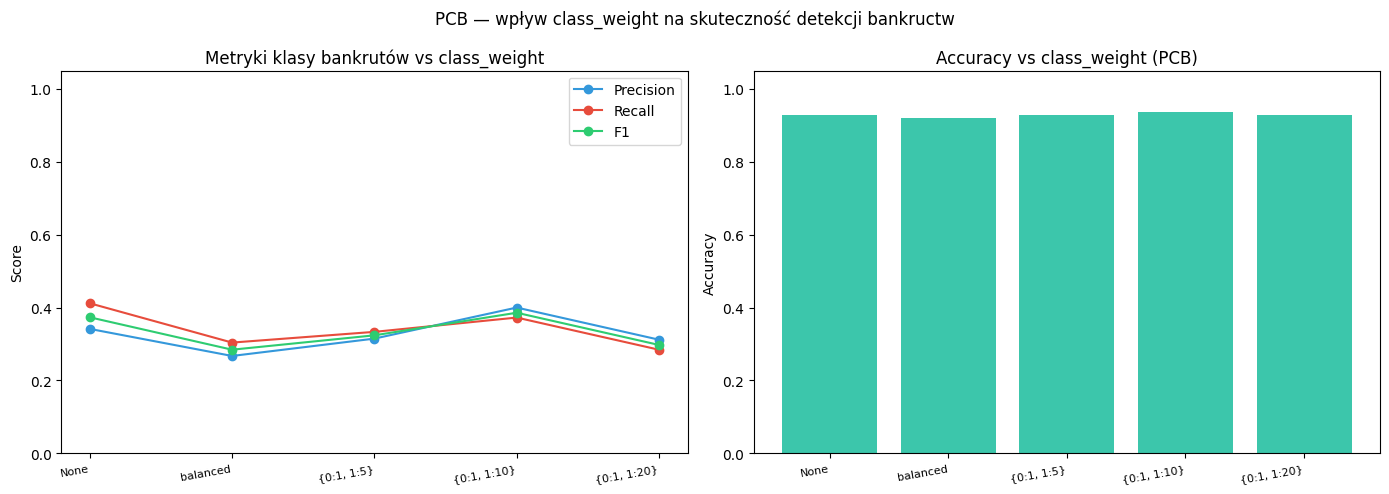

In [86]:
print('=== PCB — wpływ class_weight (zbiór testowy) ===')
display(df_cw.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, color in [('Precision', '#3498db'), ('Recall', '#e74c3c'), ('F1', '#2ecc71')]:
    axes[0].plot(range(len(df_cw)), df_cw[metric], marker='o', color=color, linewidth=1.5, label=metric)

axes[0].set_xticks(range(len(df_cw)))
axes[0].set_xticklabels(df_cw.index, rotation=10, ha='right', fontsize=8)
axes[0].set_title('Metryki klasy bankrutów vs class_weight')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar(range(len(df_cw)), df_cw['Accuracy'], color='#1abc9c', alpha=0.85)
axes[1].set_xticks(range(len(df_cw)))
axes[1].set_xticklabels(df_cw.index, rotation=10, ha='right', fontsize=8)
axes[1].set_title('Accuracy vs class_weight (PCB)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)

plt.suptitle('PCB — wpływ class_weight na skuteczność detekcji bankructw', fontsize=12)
plt.tight_layout()
plt.show()